# 1. Introdução e desenho experimental

Este notebook reconstrói, de forma didática e reproduzível, a modelagem do Capítulo 4 do TCC/MBA sobre predição de lead time portuário. A variável alvo é `t_total_port_stay_h`, isto é, o tempo total de permanência da embarcação no porto, em horas.

A pergunta operacional é: no instante da chegada ao porto (`arrival_port_ts`), quantas horas a embarcação deve permanecer até a saída? Como a previsão simula uma aplicação ao longo do tempo, o desenho experimental usa divisão temporal, e não split aleatório.

O risco metodológico central é o vazamento temporal. Uma feature só pode entrar no modelo se estiver disponível no instante da previsão ou puder ser calculada apenas com informação já conhecida. Por isso, as features históricas reconstruídas usam cutoff conservador: para uma chegada no dia D, apenas informações conhecidas até 23:59:59 de D-1 podem ser usadas.

Os conjuntos têm papéis distintos: `train` ajusta os modelos; `validation` seleciona modelo, features e hiperparâmetros; `calibration` funciona como verificação secundária; `final_test` permanece fechado até a especificação estar congelada.

# 2. Imports, configuração e reprodutibilidade

Esta seção define constantes, caminhos e bibliotecas. O notebook começa em `data/processed/eda_base.parquet` e salva artefatos próprios em `results/cap4_notebook_run/`, preservando os resultados oficiais em `results/cap4_rebuild/`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import platform
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_pinball_loss, mean_squared_error, median_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Raiz do projeto não encontrada.")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.historical_context import add_cyclical_features, build_historical_features, run_leakage_tests

DATA_FILE = ROOT / "data" / "processed" / "eda_base.parquet"
RUN_RESULTS = ROOT / "results" / "cap4_notebook_run"
RUN_FIGURES = RUN_RESULTS / "figures"
RUN_RESULTS.mkdir(parents=True, exist_ok=True)
RUN_FIGURES.mkdir(parents=True, exist_ok=True)

TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"
PORT_COL = "port"
OPERATION_COL = "operation_type"
RANDOM_STATE = 42
MIN_GROUP_SIZE = 30
SPLIT_BOUNDS = {
    "train_start": "2023-01-01",
    "validation_start": "2024-07-01",
    "calibration_start": "2025-01-01",
    "final_test_start": "2025-07-01",
    "final_test_end": "2026-01-01",
}

In [3]:
def git_value(args: list[str]) -> str:
    try:
        return subprocess.check_output(["git", *args], cwd=ROOT, text=True, stderr=subprocess.DEVNULL).strip()
    except Exception:
        return "indisponível"

repro_context = pd.DataFrame(
    {
        "item": ["root", "branch", "commit", "python", "platform"],
        "valor": [str(ROOT), git_value(["branch", "--show-current"]), git_value(["rev-parse", "HEAD"]), platform.python_version(), platform.platform()],
    }
)
repro_context

,item,valor
0,root,G:\My Drive\Graduação e Pós\USP\MBA USP IA e B...
1,branch,cap4/rebuild-safe-historical-features
2,commit,3d584cc87f727eecb63f088324ba7be02756c20d
3,python,3.11.15
4,platform,Windows-10-10.0.26200-SP0


# 3. Carregamento da base de modelagem

A base de partida da modelagem é `eda_base.parquet`. Ela contém a base analítica consolidada, mas as features históricas temporalmente seguras serão reconstruídas explicitamente mais adiante neste notebook.

In [4]:
df_raw = pd.read_parquet(DATA_FILE)
for col in [DATE_COL, "berthing_ts", "unberthing_ts", "departure_port_ts"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

base_summary = pd.DataFrame(
    {
        "item": ["registros", "colunas", "menor chegada", "maior chegada", "target", "target médio (h)", "target mediano (h)"],
        "valor": [len(df_raw), df_raw.shape[1], df_raw[DATE_COL].min(), df_raw[DATE_COL].max(), TARGET, df_raw[TARGET].mean(), df_raw[TARGET].median()],
    }
)
base_summary

,item,valor
0,registros,129625
1,colunas,126
2,menor chegada,2023-01-01 00:08:00
3,maior chegada,2025-12-31 23:00:00
4,target,t_total_port_stay_h
5,target médio (h),71.104
6,target mediano (h),38.417


In [5]:
important_cols = [
    "port_call_id", PORT_COL, "port_display", OPERATION_COL, "vessel_id", "source_port", "destination_port",
    DATE_COL, "berthing_ts", "unberthing_ts", "departure_port_ts", TARGET,
]
df_raw[[col for col in important_cols if col in df_raw.columns]].head()

,port_call_id,port,port_display,operation_type,vessel_id,source_port,destination_port,arrival_port_ts,berthing_ts,unberthing_ts,departure_port_ts,t_total_port_stay_h
0,22023,BR052001,BR052001 - JURITI - PA,Carga e Descarga,11431725,BRAMW001,BRAMW001,2023-01-04 16:17:00,2023-01-04 16:17:00,2023-01-05 21:34:00,2023-01-05 21:34:00,29.283
1,5492023,BR052001,BR052001 - JURITI - PA,Carga e Descarga,<NA>,BRAMW001,BRAMW001,2023-01-06 05:18:00,2023-01-06 05:18:00,2023-01-07 11:12:00,2023-01-07 11:12:00,29.900
2,262023,BR052001,BR052001 - JURITI - PA,Carga e Descarga,<NA>,BRSTM,BRPNG,2023-01-09 06:36:00,2023-01-09 06:36:00,2023-01-10 17:42:00,2023-01-10 17:42:00,35.100
3,12602023,BR052001,BR052001 - JURITI - PA,Carga,<NA>,BRAMW001,BRJUR,2023-01-10 20:45:00,2023-01-10 20:45:00,2023-01-12 04:30:00,2023-01-12 04:30:00,31.750
4,24052023,BR052001,BR052001 - JURITI - PA,Carga e Descarga,11437804,BRAMW001,BRAMW001,2023-01-17 18:46:00,2023-01-17 18:46:00,2023-01-19 11:55:00,2023-01-19 11:55:00,41.150


In [6]:
df_raw[TARGET].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("horas")

,horas
count,"129,625.000"
mean,71.104
std,97.116
min,0.017
50%,38.417
75%,80.833
90%,163.083
95%,253.733
99%,527.853
max,"1,280.083"


# 4. Features originais do Capítulo 4

O conjunto `ORIGINAL` reproduz as variáveis usadas antes do enriquecimento histórico seguro. Elas são separadas em famílias para deixar claro o papel de cada grupo: estrutura/geografia, calendário, clima histórico defasado e flags operacionais declaradas.

In [ ]:
def chapter4_feature_lists(df: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    categorical = ["port", "region", "state", "arrival_shift", "arrival_season"]
    calendar = [
        "arrival_quarter", "arrival_weekofyear", "arrival_is_weekend",
        "arrival_hour_sin", "arrival_hour_cos", "arrival_dow_sin", "arrival_dow_cos",
        "arrival_month_sin", "arrival_month_cos",
    ]
    weather = [
        "rain_sum_prev_1d", "precipitation_sum_prev_1d", "wind_speed_10m_max_prev_1d",
        "wind_gusts_10m_max_prev_1d", "temperature_2m_mean_prev_1d",
        "rain_sum_prev_3d", "precipitation_hours_prev_3d", "temperature_2m_mean_prev_3d",
        "wind_speed_10m_max_prev_3d", "wind_gusts_10m_max_prev_3d",
        "rain_sum_prev_7d", "precipitation_hours_prev_7d", "temperature_2m_mean_prev_7d",
        "wind_speed_10m_max_prev_7d", "wind_gusts_10m_max_prev_7d",
    ]
    operation = sorted(col for col in df.columns if col.startswith("op_"))
    categorical = [col for col in categorical if col in df.columns]
    numerical = [col for col in calendar + weather if col in df.columns]
    operation = [col for col in operation if col in df.columns]
    return categorical, numerical, operation

feature_family_original = {
    "estruturais_geograficas": ["port", "region", "state"],
    "temporais_calendario": [
        "arrival_shift", "arrival_season", "arrival_quarter", "arrival_weekofyear", "arrival_is_weekend",
        "arrival_hour_sin", "arrival_hour_cos", "arrival_dow_sin", "arrival_dow_cos", "arrival_month_sin", "arrival_month_cos",
    ],
    "clima_historico_defasado": [col for col in df_raw.columns if col.endswith(("_prev_1d", "_prev_3d", "_prev_7d")) 
                                 and col.startswith(("rain_", "precipitation_", "wind_", "temperature_"))],
    "flags_operacionais": sorted(col for col in df_raw.columns if col.startswith("op_")),
}

original_family_table = pd.DataFrame(
    [{"familia": family, "n_features": len(cols), "exemplos": ", ".join(cols[:8])} for family, cols in feature_family_original.items()]
)
original_family_table

,familia,n_features,exemplos
0,estruturais_geograficas,3,"port, region, state"
1,temporais_calendario,11,"arrival_shift, arrival_season, arrival_quarter..."
2,clima_historico_defasado,15,"rain_sum_prev_1d, precipitation_sum_prev_1d, w..."
3,flags_operacionais,17,"op_abastecimento_bunker, op_arribada, op_carga..."


# 5. Construção das variáveis temporais/cíclicas

Hora, dia da semana e mês são variáveis cíclicas: 23h e 0h estão próximas, assim como dezembro e janeiro. A transformação seno/cosseno representa essa circularidade sem criar uma ruptura artificial nas fronteiras do calendário.

In [ ]:
df = df_raw.dropna(subset=[DATE_COL, TARGET]).copy()
df = df[(df[DATE_COL] >= SPLIT_BOUNDS["train_start"]) & (df[DATE_COL] < SPLIT_BOUNDS["final_test_end"])].copy()
df = add_cyclical_features(df)

cyclical_examples = ["arrival_hour", "arrival_hour_sin", "arrival_hour_cos", "arrival_dayofweek", "arrival_dow_sin", 
                     "arrival_dow_cos", "arrival_month", "arrival_month_sin", "arrival_month_cos"]
df[[col for col in cyclical_examples if col in df.columns]].head(10)

,arrival_hour,arrival_hour_sin,arrival_hour_cos,arrival_dayofweek,arrival_dow_sin,arrival_dow_cos,arrival_month,arrival_month_sin,arrival_month_cos
0,16,-0.866,-0.500,2,0.975,-0.223,1,0.000,1.000
1,5,0.966,0.259,4,-0.434,-0.901,1,0.000,1.000
2,6,1.000,0.000,0,0.000,1.000,1,0.000,1.000
3,20,-0.866,0.500,1,0.782,0.623,1,0.000,1.000
4,18,-1.000,-0.000,1,0.782,0.623,1,0.000,1.000
5,11,0.259,-0.966,4,-0.434,-0.901,1,0.000,1.000
6,15,-0.707,-0.707,0,0.000,1.000,1,0.000,1.000
7,10,0.500,-0.866,2,0.975,-0.223,1,0.000,1.000
8,4,0.866,0.500,6,-0.782,0.623,1,0.000,1.000
9,7,0.966,-0.259,5,-0.975,-0.223,2,0.500,0.866


# 8. Reconstrução das features históricas temporalmente seguras

Nesta etapa o notebook executa de fato a reconstrução das features históricas. A diferença em relação ao conjunto `ORIGINAL` é que `ENRICHED_SAFE_HISTORY` incorpora memória operacional e estatísticas conhecidas antes do cutoff de cada escala.

A regra temporal é conservadora: para prever uma escala, somente informação conhecida antes do cutoff definido para ela pode participar das features históricas. Durações de espera, operação e permanência total só entram no histórico depois dos eventos que as tornam conhecidas.

In [ ]:
@dataclass(frozen=True)
class FeatureRegistry:
    original_features: list[str]
    enriched_features: list[str]
    categorical_features: list[str]
    numerical_features: list[str]
    operation_features: list[str]
    historical_families: dict[str, list[str]]
    feature_metadata: dict[str, str]

categorical_features, numerical_features, operation_features = chapter4_feature_lists(df)
original_features = categorical_features + numerical_features + operation_features

historical = build_historical_features(df, operation_features)
df_model = historical.data.copy()
family_order = ["flow", "port_performance", "state", "vessel_history", "vessel_port_history", "source_history", "destination_history", 
                "route_history", "operation_mix"]
historical_cols = []
for family in family_order:
    historical_cols.extend(historical.families.get(family, []))

enriched_features = list(dict.fromkeys(original_features + historical_cols))
registry = FeatureRegistry(original_features, enriched_features, categorical_features, numerical_features, operation_features, 
                           historical.families, historical.metadata)

pd.DataFrame(
    [{"familia": family, "n_features": len(cols), "exemplos": ", ".join(cols[:6])} for family, cols in historical.families.items()]
)

,familia,n_features,exemplos
0,flow,17,"arrivals_prev_1d, arrivals_prev_3d, arrivals_p..."
1,state,5,"state_waiting_vessels_d_minus_1, state_berthed..."
2,operation_mix,10,"opmix_carga_share_prev_3d, opmix_descarga_shar..."
3,port_performance,18,"port_wait_known_count, port_wait_known_mean, p..."
4,vessel_history,8,"vessel_total_known_count, vessel_total_known_m..."
5,vessel_port_history,4,"vessel_port_total_known_count, vessel_port_tot..."
6,source_history,4,"source_total_known_count, source_total_known_m..."
7,destination_history,4,"destination_total_known_count, destination_tot..."
8,route_history,4,"route_total_known_count, route_total_known_mea..."
9,additional_safe_history,34,"vessel_total_known_count, vessel_total_known_m..."


In [10]:
sample_historical_cols = [
    "cutoff_ts", "arrivals_prev_1d", "departures_prev_1d", "flow_balance_prev_1d",
    "state_waiting_vessels_d_minus_1", "port_total_known_median", "vessel_total_known_median",
    "vessel_port_total_known_median", "source_total_known_median", "destination_total_known_median", "route_total_known_median",
]
shown_cols = [col for col in ["port_call_id", PORT_COL, OPERATION_COL, DATE_COL, TARGET] + sample_historical_cols if col in df_model.columns]
df_model[shown_cols].head(12)

,port_call_id,port,operation_type,arrival_port_ts,t_total_port_stay_h,cutoff_ts,arrivals_prev_1d,departures_prev_1d,flow_balance_prev_1d,state_waiting_vessels_d_minus_1,port_total_known_median,vessel_total_known_median,vessel_port_total_known_median,source_total_known_median,destination_total_known_median,route_total_known_median
0,22023,BR052001,Carga e Descarga,2023-01-04 16:17:00,29.283,2023-01-03 23:59:59,0.000,0.000,0.000,0.000,NaN,NaN,NaN,19.108,NaN,NaN
1,5492023,BR052001,Carga e Descarga,2023-01-06 05:18:00,29.900,2023-01-05 23:59:59,0.000,1.000,-1.000,0.000,29.283,NaN,NaN,29.283,29.283,29.283
2,262023,BR052001,Carga e Descarga,2023-01-09 06:36:00,35.100,2023-01-08 23:59:59,0.000,0.000,0.000,0.000,29.592,NaN,NaN,NaN,21.750,NaN
3,12602023,BR052001,Carga,2023-01-10 20:45:00,31.750,2023-01-09 23:59:59,1.000,0.000,1.000,0.000,29.592,NaN,NaN,29.283,NaN,NaN
4,24052023,BR052001,Carga e Descarga,2023-01-17 18:46:00,41.150,2023-01-16 23:59:59,0.000,0.000,0.000,0.000,30.825,34.400,NaN,29.592,29.283,29.283
5,27992023,BR052001,Carga e Descarga,2023-01-20 11:15:00,29.300,2023-01-19 23:59:59,0.000,1.000,-1.000,0.000,31.750,30.167,29.283,30.825,29.592,29.592
6,33492023,BR052001,Carga,2023-01-23 15:00:00,26.300,2023-01-22 23:59:59,0.000,0.000,0.000,0.000,30.825,NaN,NaN,29.900,29.300,29.300
7,35842023,BR052001,Carga,2023-01-25 10:54:00,40.000,2023-01-24 23:59:59,0.000,1.000,-1.000,0.000,29.900,NaN,NaN,34.167,32.958,34.167
8,40072023,BR052001,Carga e Descarga,2023-01-29 04:05:00,28.850,2023-01-28 23:59:59,0.000,0.000,0.000,0.000,30.825,34.800,41.150,31.750,29.300,29.292
9,50802023,BR052001,Carga,2023-02-04 07:00:00,34.900,2023-02-03 23:59:59,0.000,0.000,0.000,0.000,29.900,NaN,NaN,29.900,29.292,29.283


# 9. Testes de leakage temporal

Os testes adversariais verificam se a reconstrução impede uso do próprio evento, eventos futuros, dias sem movimento mal tratados e estatísticas conhecidas somente após berthing, unberthing ou departure.

In [11]:
leakage_tests = run_leakage_tests()
leakage_tests.to_csv(RUN_RESULTS / "leakage_tests.csv", index=False)
leakage_tests

,test,passed,detail
0,evento_do_proprio_dia_nao_altera_features_d_me...,True,Evento em D nao afetou fluxo com cutoff D-1.
1,evento_futuro_nao_altera_features_passadas,True,Evento futuro em fevereiro nao afetou corte de...
2,espera_so_disponivel_depois_da_atracacao,True,"counts=0.0,1.0"
3,operacao_so_disponivel_depois_da_desatracacao,True,"counts=0.0,1.0"
4,permanencia_so_disponivel_depois_da_saida,True,"counts=0.0,1.0"
5,dias_calendario_sem_eventos_existem_com_zero,True,Jan 4 arrivals_prev_1d=0.0
6,target_da_propria_observacao_nao_entra_na_feature,True,known count=0.0
7,rolling_nao_usa_linhas_futuras,True,D-1 de 2024-01-03 e 2024-01-02: 0.0
8,merge_exclui_eventos_conhecidos_no_futuro,True,searchsorted side='right' aplica cutoff_ts.
9,imputacao_ajustada_apenas_no_treino,True,"statistics before=2.0, after=2.0"


In [12]:
if not leakage_tests["passed"].all():
    raise RuntimeError("Pelo menos um teste de leakage falhou. Interrompa a análise antes de modelar.")
print("Todos os testes de leakage passaram.")

Todos os testes de leakage passaram.


# 10. Divisão temporal

Os splits são criados programaticamente com os limites oficiais. Até este ponto, `final_test` não participa de seleção de modelo ou hiperparâmetro.

In [13]:
def split_data(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {
        "train": df[(df[DATE_COL] >= SPLIT_BOUNDS["train_start"]) & (df[DATE_COL] < SPLIT_BOUNDS["validation_start"])].copy(),
        "validation": df[(df[DATE_COL] >= SPLIT_BOUNDS["validation_start"]) & (df[DATE_COL] < SPLIT_BOUNDS["calibration_start"])].copy(),
        "calibration": df[(df[DATE_COL] >= SPLIT_BOUNDS["calibration_start"]) & (df[DATE_COL] < SPLIT_BOUNDS["final_test_start"])].copy(),
        "final_test": df[(df[DATE_COL] >= SPLIT_BOUNDS["final_test_start"]) & (df[DATE_COL] < SPLIT_BOUNDS["final_test_end"])].copy(),
    }

splits = split_data(df_model)
split_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "primeira_data": part[DATE_COL].min(),
            "ultima_data": part[DATE_COL].max(),
            "n_observacoes": len(part),
            "target_medio_h": part[TARGET].mean(),
            "target_mediano_h": part[TARGET].median(),
        }
        for name, part in splits.items()
    ]
)
split_summary.to_csv(RUN_RESULTS / "split_summary.csv", index=False)
split_summary

,dataset,primeira_data,ultima_data,n_observacoes,target_medio_h,target_mediano_h
0,train,2023-01-01 00:08:00,2024-06-30 23:30:00,66909,70.020,36.900
1,validation,2024-07-01 00:00:00,2024-12-31 22:40:00,20362,77.414,42.508
2,calibration,2025-01-01 00:05:00,2025-06-30 23:40:00,21352,69.176,37.833
3,final_test,2025-07-01 00:00:00,2025-12-31 23:00:00,21002,70.399,39.717


# 11. Métricas de avaliação

O MAE é a métrica principal porque mede erro médio em horas, diretamente interpretável para a decisão operacional. RMSE penaliza erros grandes, MedAE descreve erro típico robusto e RMSLE reduz o peso relativo da longa cauda. As métricas Q90/Q95 avaliam o comportamento nos casos extremos, importantes para estoque de segurança.

In [ ]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.clip(np.asarray(y_true, dtype=float), 0, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "medae": float(median_absolute_error(y_true, y_pred)),
        "rmsle": rmsle(y_true, y_pred),
    }


def tail_metrics(y_true: np.ndarray, y_pred: np.ndarray, q90_threshold: float, q95_threshold: float) -> dict[str, float | int]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    out = {"q90_threshold_h": float(q90_threshold), "q95_threshold_h": float(q95_threshold)}
    for label, threshold in [("q90", q90_threshold), ("q95", q95_threshold)]:
        mask = y_true >= threshold
        errors = y_pred[mask] - y_true[mask]
        out[f"n_{label}"] = int(mask.sum())
        out[f"mae_{label}"] = float(np.abs(errors).mean()) if mask.any() else np.nan
        out[f"bias_{label}"] = float(errors.mean()) if mask.any() else np.nan
        out[f"underprediction_rate_{label}"] = float((errors < 0).mean()) if mask.any() else np.nan
    return out


def score_row(model: str, feature_config: str, dataset: str, y_true: np.ndarray, y_pred: np.ndarray, q90: float, q95: float, 
              extra: dict[str, object] | None = None) -> dict[str, object]:
    row = {"model": model, "feature_config": feature_config, "dataset": dataset, **regression_metrics(y_true, y_pred), 
           **tail_metrics(y_true, y_pred, q90, q95)}
    if extra:
        row.update(extra)
    return row

# 12. Baselines históricos

Os baselines representam políticas históricas simples calculadas apenas sobre o treino: mediana global, mediana por porto e mediana hierárquica porto × tipo de operação com fallback.

In [15]:
def group_quantile_prediction(train: pd.DataFrame, scoring: pd.DataFrame, group_cols: list[str], quantile: float, min_group_size: int = 1) -> np.ndarray:
    global_q = train[TARGET].quantile(quantile)
    stats = train.groupby(group_cols, dropna=False)[TARGET].agg(q=lambda x: x.quantile(quantile), count="count").reset_index()
    stats.loc[stats["count"] < min_group_size, "q"] = np.nan
    scored = scoring[group_cols].copy().merge(stats[group_cols + ["q"]], on=group_cols, how="left")
    return scored["q"].fillna(global_q).to_numpy(dtype=float)


def hierarchical_quantile_prediction(train: pd.DataFrame, scoring: pd.DataFrame, quantile: float, primary_cols: list[str] | None = None, fallback_cols: list[str] | None = None, min_group_size: int = MIN_GROUP_SIZE) -> np.ndarray:
    primary_cols = primary_cols or [PORT_COL, OPERATION_COL]
    fallback_cols = fallback_cols or [PORT_COL]
    global_q = train[TARGET].quantile(quantile)
    primary = train.groupby(primary_cols, dropna=False)[TARGET].agg(q=lambda x: x.quantile(quantile), count="count").reset_index()
    primary = primary[primary["count"] >= min_group_size][primary_cols + ["q"]].rename(columns={"q": "primary_q"})
    fallback = train.groupby(fallback_cols, dropna=False)[TARGET].agg(q=lambda x: x.quantile(quantile), count="count").reset_index()
    fallback = fallback[fallback["count"] >= min_group_size][fallback_cols + ["q"]].rename(columns={"q": "fallback_q"})
    out = scoring[primary_cols].copy().merge(primary, on=primary_cols, how="left").merge(fallback, on=fallback_cols, how="left")
    return out["primary_q"].fillna(out["fallback_q"]).fillna(global_q).to_numpy(dtype=float)

train = splits["train"]
validation = splits["validation"]
calibration = splits["calibration"]
q90_train = float(train[TARGET].quantile(0.90))
q95_train = float(train[TARGET].quantile(0.95))

baseline_predictions = {
    "baseline_global_median": np.repeat(train[TARGET].median(), len(validation)),
    "baseline_median_by_port": group_quantile_prediction(train, validation, [PORT_COL], 0.50),
    "baseline_hierarchical_port_operation": hierarchical_quantile_prediction(train, validation, 0.50),
}
baseline_validation = pd.DataFrame([
    score_row(name, "ORIGINAL", "validation", validation[TARGET], pred, q90_train, q95_train)
    for name, pred in baseline_predictions.items()
])
baseline_validation.to_csv(RUN_RESULTS / "baseline_validation.csv", index=False)
baseline_validation

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95
0,baseline_global_median,ORIGINAL,validation,56.363,112.085,23.933,1.100,161.417,254.133,2378,270.244,-270.244,1.000,1195,376.893,-376.893,1.000
1,baseline_median_by_port,ORIGINAL,validation,52.102,108.128,20.667,0.982,161.417,254.133,2378,256.895,-256.851,0.999,1195,363.559,-363.494,0.999
2,baseline_hierarchical_port_operation,ORIGINAL,validation,47.864,100.997,19.283,0.895,161.417,254.133,2378,233.397,-233.256,0.997,1195,338.958,-338.958,1.000


# 13. Funções auxiliares de preprocessing

Ridge, Random Forest e Gradient Boosting usam imputação para numéricas, one-hot encoding para categóricas e scaling apenas no Ridge. O HistGradientBoosting recebe colunas categóricas como `category`, aprendendo categorias somente a partir do treino.

In [16]:
def build_preprocessor(numeric_features: list[str], categorical_features: list[str], scale_numeric: bool = False) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", Pipeline(numeric_steps), numeric_features), ("cat", categorical_pipeline, categorical_features)])


def prepare_hgb_frames(train_df: pd.DataFrame, eval_df: pd.DataFrame, features: list[str], categorical_features: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    x_train = train_df[features].copy()
    x_eval = eval_df[features].copy()
    for col in categorical_features:
        if col not in features:
            continue
        categories = pd.Index(x_train[col].astype("string").dropna().astype(str).unique())
        x_train[col] = pd.Categorical(x_train[col].astype("string"), categories=categories)
        x_eval[col] = pd.Categorical(x_eval[col].astype("string"), categories=categories)
    return x_train, x_eval


def append_eval_scores(rows: list[dict[str, object]], label: str, feature_config: str, pred_eval: np.ndarray, extra: dict[str, object] | None = None) -> None:
    n_val = len(validation)
    for dataset, part, pred in [("validation", validation, pred_eval[:n_val]), ("calibration", calibration, pred_eval[n_val:])]:
        rows.append(score_row(label, feature_config, dataset, part[TARGET], pred, q90_train, q95_train, extra=extra))

# 14. Transformação do target

Os modelos pontuais são treinados com `np.log1p(y_train)` e as previsões retornam para horas com `np.expm1(...)`, truncadas em zero. Essa transformação reduz a influência da assimetria e da longa cauda sem mudar a unidade de interpretação dos resultados finais.

In [17]:
y_train_log = np.log1p(train[TARGET].to_numpy(dtype=float))
pd.DataFrame({"target_h": train[TARGET].head(5).to_numpy(), "log1p_target": y_train_log[:5]})

,target_h,log1p_target
0,29.283,3.411
1,29.900,3.431
2,35.100,3.586
3,31.750,3.489
4,41.150,3.741


# 15. Ridge Regression

O Ridge é treinado com target log-transformado. A busca de `alpha` usa exatamente os candidatos da execução canônica: `0.01`, `0.1`, `1.0`, `10.0` e `100.0`, sempre selecionando pelo desempenho em `validation`.

In [18]:
def tune_ridge_alpha_visible(features: list[str], config_name: str) -> tuple[float, pd.DataFrame]:
    rows = []
    numeric_features = [col for col in features if col not in categorical_features]
    for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
        candidate_ridge = Pipeline([
            ("preprocessor", build_preprocessor(numeric_features, [col for col in categorical_features if col in features], True)),
            ("model", Ridge(alpha=float(alpha))),
        ])
        candidate_ridge.fit(train[features], np.log1p(train[TARGET].to_numpy(dtype=float)))
        pred_validation = np.clip(np.expm1(candidate_ridge.predict(validation[features])), 0, None)
        rows.append({"feature_config": config_name, "alpha": alpha, **regression_metrics(validation[TARGET], pred_validation)})
    table = pd.DataFrame(rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
    return float(table.iloc[0]["alpha"]), table

ridge_alpha_original, ridge_alpha_table_original = tune_ridge_alpha_visible(original_features, "ORIGINAL")
ridge_alpha_enriched, ridge_alpha_table_enriched = tune_ridge_alpha_visible(enriched_features, "ENRICHED_SAFE_HISTORY")
ridge_alpha_table = pd.concat([ridge_alpha_table_original, ridge_alpha_table_enriched], ignore_index=True)
ridge_alpha_table.to_csv(RUN_RESULTS / "ridge_alpha_validation.csv", index=False)
ridge_alpha_table

,feature_config,alpha,mae,rmse,medae,rmsle
0,ORIGINAL,10.000,53.120,130.497,20.332,0.939
1,ORIGINAL,1.000,53.208,132.225,20.377,0.939
2,ORIGINAL,0.100,53.253,132.755,20.390,0.940
3,ORIGINAL,0.010,53.258,132.884,20.385,0.940
4,ORIGINAL,100.000,53.271,130.903,20.260,0.944
5,ENRICHED_SAFE_HISTORY,100.000,48.080,100.725,19.304,0.870
6,ENRICHED_SAFE_HISTORY,10.000,48.142,100.682,19.573,0.870
7,ENRICHED_SAFE_HISTORY,1.000,48.195,100.659,19.648,0.871
8,ENRICHED_SAFE_HISTORY,0.100,48.215,100.662,19.640,0.872
9,ENRICHED_SAFE_HISTORY,0.010,48.220,100.663,19.645,0.872


In [19]:
eval_model = pd.concat([validation, calibration], ignore_index=True)
point_rows = []
point_models = {}
point_predictions_eval = {}

ridge_original_features = original_features
ridge_original_numeric = [col for col in ridge_original_features if col not in categorical_features]
ridge_original_model = Pipeline([
    ("preprocessor", build_preprocessor(ridge_original_numeric, [col for col in categorical_features if col in ridge_original_features], True)),
    ("model", Ridge(alpha=ridge_alpha_original)),
])
ridge_original_model.fit(train[ridge_original_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
ridge_original_pred_eval = np.clip(np.expm1(ridge_original_model.predict(eval_model[ridge_original_features])), 0, None)
point_models[("Ridge", "ORIGINAL")] = ridge_original_model
point_predictions_eval[("Ridge", "ORIGINAL")] = ridge_original_pred_eval
append_eval_scores(point_rows, "Ridge", "ORIGINAL", ridge_original_pred_eval, {"ridge_alpha": ridge_alpha_original})

ridge_enriched_features = enriched_features
ridge_enriched_numeric = [col for col in ridge_enriched_features if col not in categorical_features]
ridge_enriched_model = Pipeline([
    ("preprocessor", build_preprocessor(ridge_enriched_numeric, [col for col in categorical_features if col in ridge_enriched_features], True)),
    ("model", Ridge(alpha=ridge_alpha_enriched)),
])
ridge_enriched_model.fit(train[ridge_enriched_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
ridge_enriched_pred_eval = np.clip(np.expm1(ridge_enriched_model.predict(eval_model[ridge_enriched_features])), 0, None)
point_models[("Ridge", "ENRICHED_SAFE_HISTORY")] = ridge_enriched_model
point_predictions_eval[("Ridge", "ENRICHED_SAFE_HISTORY")] = ridge_enriched_pred_eval
append_eval_scores(point_rows, "Ridge", "ENRICHED_SAFE_HISTORY", ridge_enriched_pred_eval, {"ridge_alpha": ridge_alpha_enriched})

pd.DataFrame([row for row in point_rows if row["model"] == "Ridge"])

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95,ridge_alpha
0,Ridge,ORIGINAL,validation,53.120,130.497,20.332,0.939,161.417,254.133,2378,244.579,-240.255,0.995,1195,347.723,-344.885,0.997,10.000
1,Ridge,ORIGINAL,calibration,47.011,121.917,18.589,0.920,161.417,254.133,2048,235.694,-233.429,0.995,946,346.803,-346.734,0.999,10.000
2,Ridge,ENRICHED_SAFE_HISTORY,validation,48.080,100.725,19.304,0.870,161.417,254.133,2378,222.650,-219.407,0.984,1195,321.805,-319.557,0.994,100.000
3,Ridge,ENRICHED_SAFE_HISTORY,calibration,43.451,167.043,17.696,0.861,161.417,254.133,2048,218.552,-214.850,0.982,946,326.517,-323.853,0.990,100.000


# 16. Random Forest

O Random Forest usa a configuração canônica: `n_estimators=250`, `min_samples_leaf=50`, `max_features=1.0`, `random_state=42` e `n_jobs=-1`.

In [20]:
rf_original_features = original_features
rf_original_numeric = [col for col in rf_original_features if col not in categorical_features]
rf_original_model = Pipeline([
    ("preprocessor", build_preprocessor(rf_original_numeric, [col for col in categorical_features if col in rf_original_features], False)),
    ("model", RandomForestRegressor(n_estimators=250, min_samples_leaf=50, max_features=1.0, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_original_model.fit(train[rf_original_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
rf_original_pred_eval = np.clip(np.expm1(rf_original_model.predict(eval_model[rf_original_features])), 0, None)
point_models[("Random Forest", "ORIGINAL")] = rf_original_model
point_predictions_eval[("Random Forest", "ORIGINAL")] = rf_original_pred_eval
append_eval_scores(point_rows, "Random Forest", "ORIGINAL", rf_original_pred_eval)

rf_enriched_features = enriched_features
rf_enriched_numeric = [col for col in rf_enriched_features if col not in categorical_features]
rf_enriched_model = Pipeline([
    ("preprocessor", build_preprocessor(rf_enriched_numeric, [col for col in categorical_features if col in rf_enriched_features], False)),
    ("model", RandomForestRegressor(n_estimators=250, min_samples_leaf=50, max_features=1.0, random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_enriched_model.fit(train[rf_enriched_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
rf_enriched_pred_eval = np.clip(np.expm1(rf_enriched_model.predict(eval_model[rf_enriched_features])), 0, None)
point_models[("Random Forest", "ENRICHED_SAFE_HISTORY")] = rf_enriched_model
point_predictions_eval[("Random Forest", "ENRICHED_SAFE_HISTORY")] = rf_enriched_pred_eval
append_eval_scores(point_rows, "Random Forest", "ENRICHED_SAFE_HISTORY", rf_enriched_pred_eval)

pd.DataFrame([row for row in point_rows if row["model"] == "Random Forest"])

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95
0,Random Forest,ORIGINAL,validation,47.588,99.295,19.325,0.876,161.417,254.133,2378,229.470,-229.448,0.999,1195,331.711,-331.711,1.000
1,Random Forest,ORIGINAL,calibration,42.040,87.978,17.551,0.853,161.417,254.133,2048,221.959,-221.943,1.000,946,332.938,-332.938,1.000
2,Random Forest,ENRICHED_SAFE_HISTORY,validation,45.271,95.932,18.551,0.820,161.417,254.133,2378,219.422,-219.293,0.996,1195,319.064,-319.064,1.000
3,Random Forest,ENRICHED_SAFE_HISTORY,calibration,39.804,86.238,16.101,0.799,161.417,254.133,2048,217.653,-217.518,0.996,946,330.212,-330.212,1.000


# 17. Gradient Boosting

O Gradient Boosting usa perda Huber, `n_estimators=300`, `learning_rate=0.10`, `max_depth=7`, `min_samples_leaf=20`, `subsample=1.0` e `random_state=42`.

In [21]:
gb_original_features = original_features
gb_original_numeric = [col for col in gb_original_features if col not in categorical_features]
gb_original_model = Pipeline([
    ("preprocessor", build_preprocessor(gb_original_numeric, [col for col in categorical_features if col in gb_original_features], False)),
    ("model", GradientBoostingRegressor(loss="huber", n_estimators=300, learning_rate=0.10, max_depth=7, min_samples_leaf=20, subsample=1.0, 
                                        random_state=RANDOM_STATE)),
])
gb_original_model.fit(train[gb_original_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
gb_original_pred_eval = np.clip(np.expm1(gb_original_model.predict(eval_model[gb_original_features])), 0, None)
point_models[("Gradient Boosting", "ORIGINAL")] = gb_original_model
point_predictions_eval[("Gradient Boosting", "ORIGINAL")] = gb_original_pred_eval
append_eval_scores(point_rows, "Gradient Boosting", "ORIGINAL", gb_original_pred_eval)

gb_enriched_features = enriched_features
gb_enriched_numeric = [col for col in gb_enriched_features if col not in categorical_features]
gb_enriched_model = Pipeline([
    ("preprocessor", build_preprocessor(gb_enriched_numeric, [col for col in categorical_features if col in gb_enriched_features], False)),
    ("model", GradientBoostingRegressor(loss="huber", n_estimators=300, learning_rate=0.10, max_depth=7, min_samples_leaf=20, subsample=1.0, 
                                        random_state=RANDOM_STATE)),
])
gb_enriched_model.fit(train[gb_enriched_features], np.log1p(train[TARGET].to_numpy(dtype=float)))
gb_enriched_pred_eval = np.clip(np.expm1(gb_enriched_model.predict(eval_model[gb_enriched_features])), 0, None)
point_models[("Gradient Boosting", "ENRICHED_SAFE_HISTORY")] = gb_enriched_model
point_predictions_eval[("Gradient Boosting", "ENRICHED_SAFE_HISTORY")] = gb_enriched_pred_eval
append_eval_scores(point_rows, "Gradient Boosting", "ENRICHED_SAFE_HISTORY", gb_enriched_pred_eval)

pd.DataFrame([row for row in point_rows if row["model"] == "Gradient Boosting"])

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95
0,Gradient Boosting,ORIGINAL,validation,47.607,99.513,18.992,0.877,161.417,254.133,2378,229.146,-228.664,0.993,1195,330.782,-330.702,0.997
1,Gradient Boosting,ORIGINAL,calibration,42.233,88.464,17.352,0.859,161.417,254.133,2048,222.910,-222.436,0.995,946,333.950,-333.950,1.000
2,Gradient Boosting,ENRICHED_SAFE_HISTORY,validation,45.186,94.418,18.454,0.819,161.417,254.133,2378,210.639,-208.144,0.981,1195,308.522,-306.992,0.992
3,Gradient Boosting,ENRICHED_SAFE_HISTORY,calibration,40.133,84.274,16.809,0.803,161.417,254.133,2048,204.780,-202.832,0.984,946,311.775,-311.505,0.998


# 18. HistGradientBoosting

O HistGradientBoosting usa tratamento categórico por dtype. As categorias são aprendidas no treino e reaplicadas na validação/calibração para evitar aprendizagem de categorias a partir do futuro.

In [22]:
hgb_original_features = original_features
hgb_original_x_train, hgb_original_x_eval = prepare_hgb_frames(train, eval_model, hgb_original_features, categorical_features)
hgb_original_model = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.10, max_iter=300, max_leaf_nodes=15, min_samples_leaf=20, 
                                                   l2_regularization=1.0, categorical_features="from_dtype", early_stopping=False, 
                                                   random_state=RANDOM_STATE)
hgb_original_model.fit(hgb_original_x_train, np.log1p(train[TARGET].to_numpy(dtype=float)))
hgb_original_pred_eval = np.clip(np.expm1(hgb_original_model.predict(hgb_original_x_eval)), 0, None)
point_models[("HistGradientBoosting", "ORIGINAL")] = hgb_original_model
point_predictions_eval[("HistGradientBoosting", "ORIGINAL")] = hgb_original_pred_eval
append_eval_scores(point_rows, "HistGradientBoosting", "ORIGINAL", hgb_original_pred_eval)

hgb_enriched_features = enriched_features
hgb_enriched_x_train, hgb_enriched_x_eval = prepare_hgb_frames(train, eval_model, hgb_enriched_features, categorical_features)
hgb_enriched_model = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.10, max_iter=300, max_leaf_nodes=15, min_samples_leaf=20, 
                                                   l2_regularization=1.0, categorical_features="from_dtype", early_stopping=False, 
                                                   random_state=RANDOM_STATE)
hgb_enriched_model.fit(hgb_enriched_x_train, np.log1p(train[TARGET].to_numpy(dtype=float)))
hgb_enriched_pred_eval = np.clip(np.expm1(hgb_enriched_model.predict(hgb_enriched_x_eval)), 0, None)
point_models[("HistGradientBoosting", "ENRICHED_SAFE_HISTORY")] = hgb_enriched_model
point_predictions_eval[("HistGradientBoosting", "ENRICHED_SAFE_HISTORY")] = hgb_enriched_pred_eval
append_eval_scores(point_rows, "HistGradientBoosting", "ENRICHED_SAFE_HISTORY", hgb_enriched_pred_eval)

pd.DataFrame([row for row in point_rows if row["model"] == "HistGradientBoosting"])

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95
0,HistGradientBoosting,ORIGINAL,validation,47.304,98.983,19.034,0.869,161.417,254.133,2378,227.581,-226.980,0.994,1195,329.940,-329.928,0.999
1,HistGradientBoosting,ORIGINAL,calibration,41.830,88.007,16.922,0.848,161.417,254.133,2048,221.565,-221.395,0.996,946,333.095,-333.087,0.999
2,HistGradientBoosting,ENRICHED_SAFE_HISTORY,validation,44.535,94.560,17.821,0.803,161.417,254.133,2378,213.864,-212.907,0.989,1195,313.598,-313.542,0.999
3,HistGradientBoosting,ENRICHED_SAFE_HISTORY,calibration,39.449,84.413,16.326,0.787,161.417,254.133,2048,209.764,-208.772,0.990,946,319.601,-319.601,1.000


# 19. Comparação dos modelos em validação

A comparação abaixo é construída diretamente das previsões recém-calculadas. A ordenação segue o critério oficial: MAE, depois RMSE, depois MAE na cauda Q90.

In [23]:
point_comparison = pd.DataFrame(point_rows)
validation_baseline_for_comparison = baseline_validation.rename(columns={"model": "model"}).copy()
validation_comparison = pd.concat(
    [validation_baseline_for_comparison, point_comparison.query("dataset == 'validation'")],
    ignore_index=True,
).sort_values(["mae", "rmse", "mae_q90"]).reset_index(drop=True)
validation_comparison.to_csv(RUN_RESULTS / "validation_comparison.csv", index=False)
validation_comparison[["model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle", "mae_q90", "mae_q95"]]

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95
0,HistGradientBoosting,ENRICHED_SAFE_HISTORY,validation,44.535,94.560,17.821,0.803,213.864,313.598
1,Gradient Boosting,ENRICHED_SAFE_HISTORY,validation,45.186,94.418,18.454,0.819,210.639,308.522
2,Random Forest,ENRICHED_SAFE_HISTORY,validation,45.271,95.932,18.551,0.820,219.422,319.064
3,HistGradientBoosting,ORIGINAL,validation,47.304,98.983,19.034,0.869,227.581,329.940
4,Random Forest,ORIGINAL,validation,47.588,99.295,19.325,0.876,229.470,331.711
5,Gradient Boosting,ORIGINAL,validation,47.607,99.513,18.992,0.877,229.146,330.782
6,baseline_hierarchical_port_operation,ORIGINAL,validation,47.864,100.997,19.283,0.895,233.397,338.958
7,Ridge,ENRICHED_SAFE_HISTORY,validation,48.080,100.725,19.304,0.870,222.650,321.805
8,baseline_median_by_port,ORIGINAL,validation,52.102,108.128,20.667,0.982,256.895,363.559
9,Ridge,ORIGINAL,validation,53.120,130.497,20.332,0.939,244.579,347.723


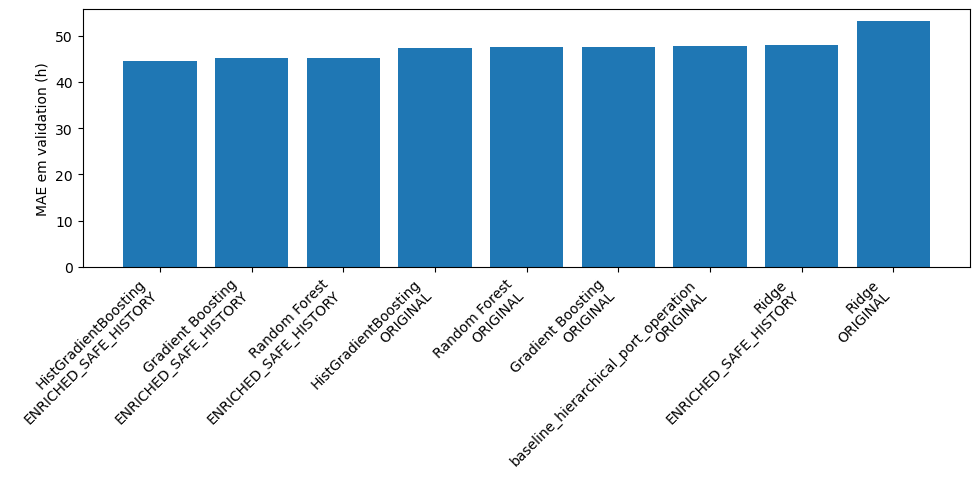

In [24]:
plt.figure(figsize=(10, 5))
plot_df = validation_comparison[validation_comparison["model"].isin(["Ridge", "Random Forest", "Gradient Boosting", 
                                                                     "HistGradientBoosting", "baseline_hierarchical_port_operation"])].copy()
labels = plot_df["model"] + "\n" + plot_df["feature_config"]
plt.bar(labels, plot_df["mae"])
plt.ylabel("MAE em validation (h)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RUN_FIGURES / "validation_model_mae.png", dpi=160)
plt.show()

# 20. Seleção programática do modelo vencedor

O vencedor emerge dos resultados em `validation`. O `final_test` ainda não foi usado.

In [25]:
winner_candidates = point_comparison[point_comparison["dataset"] == "validation"].copy()
winner = winner_candidates.sort_values(["mae", "rmse", "mae_q90"]).reset_index(drop=True).iloc[0].to_dict()
winner["selection_criterion"] = "Menor MAE em validation; desempate por RMSE e MAE na cauda Q90. Calibration é reportado como verificação secundária, sem consulta ao final_test."
pd.DataFrame([winner])[["model", "feature_config", "dataset", "mae", "rmse", "mae_q90", "selection_criterion"]]

,model,feature_config,dataset,mae,rmse,mae_q90,selection_criterion
0,HistGradientBoosting,ENRICHED_SAFE_HISTORY,validation,44.535,94.560,213.864,Menor MAE em validation; desempate por RMSE e ...


# 21. Avaliação em calibration

A calibração é usada como verificação secundária da especificação escolhida em validação. Ela não altera o modelo vencedor, as features ou os hiperparâmetros.

In [26]:
calibration_comparison = point_comparison.query("dataset == 'calibration'").sort_values(["mae", "rmse", "mae_q90"]).reset_index(drop=True)
calibration_comparison.to_csv(RUN_RESULTS / "calibration_comparison.csv", index=False)
calibration_comparison[["model", "feature_config", "dataset", "mae", "rmse", "medae", "rmsle", "mae_q90", "mae_q95"]]

,model,feature_config,dataset,mae,rmse,medae,rmsle,mae_q90,mae_q95
0,HistGradientBoosting,ENRICHED_SAFE_HISTORY,calibration,39.449,84.413,16.326,0.787,209.764,319.601
1,Random Forest,ENRICHED_SAFE_HISTORY,calibration,39.804,86.238,16.101,0.799,217.653,330.212
2,Gradient Boosting,ENRICHED_SAFE_HISTORY,calibration,40.133,84.274,16.809,0.803,204.780,311.775
3,HistGradientBoosting,ORIGINAL,calibration,41.830,88.007,16.922,0.848,221.565,333.095
4,Random Forest,ORIGINAL,calibration,42.040,87.978,17.551,0.853,221.959,332.938
5,Gradient Boosting,ORIGINAL,calibration,42.233,88.464,17.352,0.859,222.910,333.950
6,Ridge,ENRICHED_SAFE_HISTORY,calibration,43.451,167.043,17.696,0.861,218.552,326.517
7,Ridge,ORIGINAL,calibration,47.011,121.917,18.589,0.920,235.694,346.803


# 22. Congelamento da especificação final

A partir deste ponto, a especificação está congelada. O teste final pode ser aberto apenas para avaliação de generalização temporal.

In [27]:
selected_spec = {
    "modelo_selecionado": winner["model"],
    "feature_config": winner["feature_config"],
    "hiperparametros": {
        "loss": "squared_error" if winner["model"] == "HistGradientBoosting" else "ver células anteriores",
        "learning_rate": 0.10,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
        "random_state": RANDOM_STATE,
    },
    "selecao_encerrada": True,
}
pd.DataFrame([selected_spec])

,modelo_selecionado,feature_config,hiperparametros,selecao_encerrada
0,HistGradientBoosting,ENRICHED_SAFE_HISTORY,"{'loss': 'squared_error', 'learning_rate': 0.1...",True


# 23. Treinamento final

O treino final combina `train`, `validation` e `calibration`. A avaliação pareada treina novamente, do zero, o mesmo modelo vencedor com duas configurações: `ORIGINAL` e `ENRICHED_SAFE_HISTORY`. A única diferença entre os dois modelos é o conjunto de features.

In [28]:
final_train = pd.concat([train, validation, calibration], ignore_index=True)
final_test = splits["final_test"].copy()
q90_final_train = float(final_train[TARGET].quantile(0.90))
q95_final_train = float(final_train[TARGET].quantile(0.95))

final_original_features = original_features
final_original_x_train, final_original_x_test = prepare_hgb_frames(final_train, final_test, final_original_features, categorical_features)
final_original_model = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.10, max_iter=300, max_leaf_nodes=15, 
                                                     min_samples_leaf=20, l2_regularization=1.0, categorical_features="from_dtype", 
                                                     early_stopping=False, random_state=RANDOM_STATE)
final_original_model.fit(final_original_x_train, np.log1p(final_train[TARGET].to_numpy(dtype=float)))
final_original_pred = np.clip(np.expm1(final_original_model.predict(final_original_x_test)), 0, None)

final_enriched_features = enriched_features
final_enriched_x_train, final_enriched_x_test = prepare_hgb_frames(final_train, final_test, final_enriched_features, categorical_features)
final_enriched_model = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.10, max_iter=300, max_leaf_nodes=15, 
                                                     min_samples_leaf=20, l2_regularization=1.0, categorical_features="from_dtype", 
                                                     early_stopping=False, random_state=RANDOM_STATE)
final_enriched_model.fit(final_enriched_x_train, np.log1p(final_train[TARGET].to_numpy(dtype=float)))
final_enriched_pred = np.clip(np.expm1(final_enriched_model.predict(final_enriched_x_test)), 0, None)
print("Modelos finais treinados do zero.")

Modelos finais treinados do zero.


# 24. Teste final

Somente agora o `final_test` é usado. Os ganhos são calculados programaticamente a partir das previsões recém-geradas.

In [29]:
final_comparison = pd.DataFrame([
    score_row(str(winner["model"]), "ORIGINAL", "final_test", final_test[TARGET], final_original_pred, q90_final_train, q95_final_train),
    score_row(str(winner["model"]), "ENRICHED_SAFE_HISTORY", "final_test", final_test[TARGET], final_enriched_pred, q90_final_train, q95_final_train),
])
mae_original = float(final_comparison.loc[final_comparison["feature_config"] == "ORIGINAL", "mae"].iloc[0])
mae_enriched = float(final_comparison.loc[final_comparison["feature_config"] == "ENRICHED_SAFE_HISTORY", "mae"].iloc[0])
mae_gain_h = mae_original - mae_enriched
mae_gain_pct = mae_gain_h / mae_original * 100
final_comparison["mae_gain_h_vs_original"] = [0.0, mae_gain_h]
final_comparison["mae_gain_pct_vs_original"] = [0.0, mae_gain_pct]
final_comparison.to_csv(RUN_RESULTS / "final_comparison.csv", index=False)
final_comparison

,model,feature_config,dataset,mae,rmse,medae,rmsle,q90_threshold_h,q95_threshold_h,n_q90,mae_q90,bias_q90,underprediction_rate_q90,n_q95,mae_q95,bias_q95,underprediction_rate_q95,mae_gain_h_vs_original,mae_gain_pct_vs_original
0,HistGradientBoosting,ORIGINAL,final_test,41.670,83.760,17.783,0.834,163.827,255.598,2004,211.307,-211.112,0.998,963,308.003,-308.003,1.000,0.000,0.000
1,HistGradientBoosting,ENRICHED_SAFE_HISTORY,final_test,38.351,79.648,16.032,0.769,163.827,255.598,2004,198.020,-197.483,0.991,963,292.101,-292.101,1.000,3.319,7.965


In [30]:
final_predictions = final_test[[col for col in ["port_call_id", PORT_COL, "port_display", OPERATION_COL, DATE_COL, TARGET] if col in final_test.columns]].copy()
final_predictions["selected_model"] = winner["model"]
final_predictions["prediction_original_h"] = final_original_pred
final_predictions["prediction_enriched_h"] = final_enriched_pred
final_predictions["abs_error_original_h"] = np.abs(final_original_pred - final_predictions[TARGET])
final_predictions["abs_error_enriched_h"] = np.abs(final_enriched_pred - final_predictions[TARGET])
final_predictions["error_original_h"] = final_original_pred - final_predictions[TARGET]
final_predictions["error_enriched_h"] = final_enriched_pred - final_predictions[TARGET]
final_predictions["arrival_week"] = final_predictions[DATE_COL].dt.to_period("W").astype(str)
final_predictions.to_parquet(RUN_RESULTS / "final_predictions.parquet", index=False)
final_predictions.head()

,port_call_id,port,port_display,operation_type,arrival_port_ts,t_total_port_stay_h,selected_model,prediction_original_h,prediction_enriched_h,abs_error_original_h,abs_error_enriched_h,error_original_h,error_enriched_h,arrival_week
313,301352025,BR052001,BR052001 - JURITI - PA,Carga,2025-07-02 08:35:00,37.300,HistGradientBoosting,28.260,28.843,9.040,8.457,-9.040,-8.457,2025-06-30/2025-07-06
314,309482025,BR052001,BR052001 - JURITI - PA,Carga,2025-07-07 12:15:00,31.817,HistGradientBoosting,26.656,26.976,5.161,4.841,-5.161,-4.841,2025-07-07/2025-07-13
315,312662025,BR052001,BR052001 - JURITI - PA,Carga,2025-07-09 11:15:00,32.500,HistGradientBoosting,26.980,30.246,5.520,2.254,-5.520,-2.254,2025-07-07/2025-07-13
316,319602025,BR052001,BR052001 - JURITI - PA,Carga,2025-07-13 17:30:00,45.500,HistGradientBoosting,28.169,30.546,17.331,14.954,-17.331,-14.954,2025-07-07/2025-07-13
317,325252025,BR052001,BR052001 - JURITI - PA,Carga,2025-07-16 22:40:00,33.667,HistGradientBoosting,27.304,28.210,6.363,5.457,-6.363,-5.457,2025-07-14/2025-07-20


# 25. Análise da longa cauda

A cauda é avaliada no `final_test` a partir das previsões recém-geradas. Bias negativo e alta taxa de underprediction indicam subestimação de permanências longas.

In [31]:
tail_comparison = final_comparison[[
    "model", "feature_config", "dataset", "mae_q90", "mae_q95", "bias_q90", "bias_q95", "underprediction_rate_q90", "underprediction_rate_q95",
]].copy()
tail_comparison.to_csv(RUN_RESULTS / "tail_comparison.csv", index=False)
tail_comparison

,model,feature_config,dataset,mae_q90,mae_q95,bias_q90,bias_q95,underprediction_rate_q90,underprediction_rate_q95
0,HistGradientBoosting,ORIGINAL,final_test,211.307,308.003,-211.112,-308.003,0.998,1.000
1,HistGradientBoosting,ENRICHED_SAFE_HISTORY,final_test,198.020,292.101,-197.483,-292.101,0.991,1.000


In [ ]:
plt.figure(figsize=(7, 4))
plt.bar(tail_comparison["feature_config"], tail_comparison["mae_q95"])
plt.ylabel("MAE Q95 no final_test (h)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RUN_FIGURES / "tail_mae_q95.png", dpi=160)
plt.show()

# 26. Bootstrap pareado

O bootstrap estima a incerteza do ganho de erro absoluto entre `ORIGINAL` e `ENRICHED_SAFE_HISTORY`. São usados três desenhos: pareado global, blocos por semana e blocos por porto × semana.

In [32]:
def paired_bootstrap(df: pd.DataFrame, label: str, n_boot: int = 1000) -> dict[str, object]:
    diffs = df["abs_error_original_h"].to_numpy() - df["abs_error_enriched_h"].to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    reps = np.empty(n_boot)
    for i in range(n_boot):
        reps[i] = rng.choice(diffs, size=len(diffs), replace=True).mean()
    return {"method": label, "n": int(len(df)), "mean_abs_error_gain_h": float(diffs.mean()), "ci95_low_h": float(np.quantile(reps, 0.025)), 
            "ci95_high_h": float(np.quantile(reps, 0.975)), "status": "ok"}


def block_bootstrap(df: pd.DataFrame, block_cols: list[str], label: str, n_boot: int = 800) -> dict[str, object]:
    temp = df.copy()
    temp["_block"] = temp[block_cols].astype("string").fillna("__MISSING__").agg("|".join, axis=1)
    blocks = temp["_block"].drop_duplicates().to_numpy()
    if len(blocks) < 10:
        return {"method": label, "n_blocks": int(len(blocks)), "mean_abs_error_gain_h": np.nan, "ci95_low_h": np.nan, "ci95_high_h": np.nan, 
                "status": "not_enough_blocks"}
    rng = np.random.default_rng(RANDOM_STATE)
    reps = np.empty(n_boot)
    for i in range(n_boot):
        sample_blocks = rng.choice(blocks, size=len(blocks), replace=True)
        sample = pd.concat([temp[temp["_block"] == block] for block in sample_blocks], ignore_index=True)
        reps[i] = sample["abs_error_original_h"].mean() - sample["abs_error_enriched_h"].mean()
    return {"method": label, "n_blocks": int(len(blocks)), 
            "mean_abs_error_gain_h": float(temp["abs_error_original_h"].mean() - temp["abs_error_enriched_h"].mean()), 
            "ci95_low_h": float(np.quantile(reps, 0.025)), "ci95_high_h": float(np.quantile(reps, 0.975)), "status": "ok"}

bootstrap_results = pd.DataFrame([
    paired_bootstrap(final_predictions, "paired_global"),
    block_bootstrap(final_predictions, ["arrival_week"], "block_week"),
    block_bootstrap(final_predictions, [PORT_COL, "arrival_week"], "block_port_week"),
])
bootstrap_results.to_csv(RUN_RESULTS / "bootstrap_results.csv", index=False)
bootstrap_results

,method,n,mean_abs_error_gain_h,ci95_low_h,ci95_high_h,status,n_blocks
0,paired_global,"21,002.000",3.319,3.039,3.591,ok,NaN
1,block_week,NaN,3.319,3.026,3.627,ok,27.000
2,block_port_week,NaN,3.319,2.872,3.773,ok,"1,907.000"


# 27. Importância das features

A importância por permutação mede quanto o MAE aumenta quando uma feature é embaralhada. Como há correlação entre variáveis, as importâncias não devem ser somadas mecanicamente.

In [33]:
def infer_feature_family(feature: str) -> str:
    if feature in {PORT_COL, "region", "state"}:
        return "ESTRUTURAL_GEOGRAFICA"
    if feature == OPERATION_COL or feature.startswith("op_"):
        return "OPERACIONAL_DA_ESCALA"
    if feature.startswith("arrival_"):
        return "TEMPORAL"
    if feature.endswith(("_prev_1d", "_prev_3d", "_prev_7d")):
        if feature.startswith(("rain_", "precipitation_", "wind_", "temperature_")):
            return "CLIMATICA_HISTORICA"
        return "FLUXO_PORTUARIO_HISTORICO"
    return "OUTRA"


def predict_original_scale(model: object, x: pd.DataFrame) -> np.ndarray:
    return np.clip(np.expm1(model.predict(x)), 0, None)


def permutation_importance_manual(model: object, x_test: pd.DataFrame, y_true: np.ndarray, features: list[str], 
                                  original_feature_set: set[str], feature_metadata: dict[str, str], 
                                  sample_size: int = 2500, n_repeats: int = 3) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_STATE)
    if len(x_test) > sample_size:
        positions = rng.choice(len(x_test), size=sample_size, replace=False)
        x_sample = x_test.iloc[positions].copy()
        y_sample = y_true[positions]
    else:
        x_sample = x_test.copy()
        y_sample = y_true
    base_pred = predict_original_scale(model, x_sample)
    base_mae = mean_absolute_error(y_sample, base_pred)
    rows = []
    for feature in features:
        deltas = []
        for _ in range(n_repeats):
            shuffled = x_sample.copy()
            shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
            pred = predict_original_scale(model, shuffled)
            deltas.append(mean_absolute_error(y_sample, pred) - base_mae)
        rows.append({"feature": feature, "feature_origin": "original" if feature in original_feature_set else "new", 
                     "family": feature_metadata.get(feature, infer_feature_family(feature)), 
                     "importance_mae_increase_h": float(np.mean(deltas)), "importance_std_h": float(np.std(deltas)), 
                     "sample_size": int(len(x_sample))})
    return pd.DataFrame(rows).sort_values("importance_mae_increase_h", ascending=False)

feature_importance = permutation_importance_manual(final_enriched_model, final_enriched_x_test, final_test[TARGET].to_numpy(dtype=float), 
                                                   enriched_features, set(original_features), registry.feature_metadata)
feature_importance.to_csv(RUN_RESULTS / "feature_importance.csv", index=False)
feature_importance.head(20)

,feature,feature_origin,family,importance_mae_increase_h,importance_std_h,sample_size
0,port,original,ESTRUTURAL_GEOGRAFICA,5.308,0.032,2500
108,route_total_known_median,new,HISTORICO_DE_ROTA,2.365,0.223,2500
31,op_carga,original,OPERACIONAL_DA_ESCALA,1.547,0.195,2500
32,op_descarga,original,OPERACIONAL_DA_ESCALA,1.235,0.075,2500
100,source_total_known_median,new,HISTORICO_DE_ORIGEM,0.826,0.098,2500
81,state_waiting_vessels_d_minus_1,new,ESTADO_OPERACIONAL_RECONSTRUIDO_D_1,0.779,0.097,2500
96,vessel_port_total_known_median,new,HISTORICO_EMBARCACAO_PORTO,0.419,0.087,2500
33,op_desembarque_passageiros,original,OPERACIONAL_DA_ESCALA,0.393,0.077,2500
99,source_total_known_mean,new,HISTORICO_DE_ORIGEM,0.360,0.021,2500
95,vessel_port_total_known_mean,new,HISTORICO_EMBARCACAO_PORTO,0.342,0.075,2500


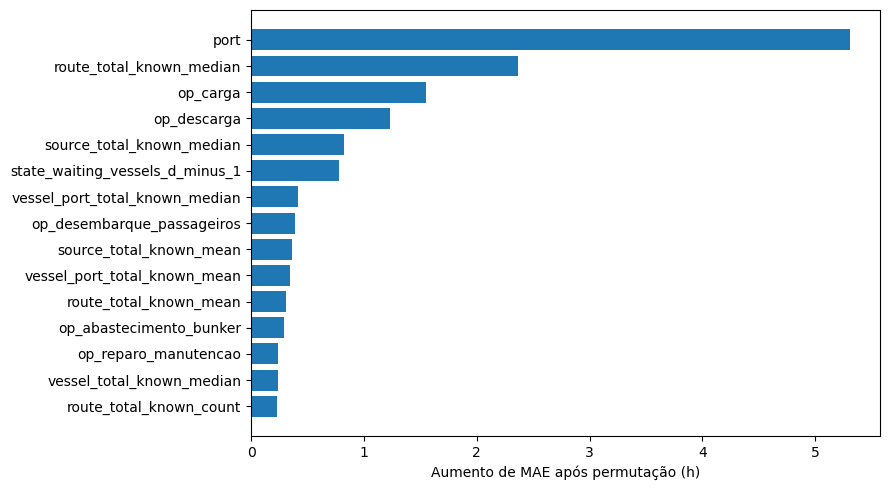

In [34]:
plt.figure(figsize=(9, 5))
top_imp = feature_importance.head(15).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance_mae_increase_h"])
plt.xlabel("Aumento de MAE após permutação (h)")
plt.tight_layout()
plt.savefig(RUN_FIGURES / "feature_importance_top15.png", dpi=160)
plt.show()

# 28. Ablation / valor incremental das famílias de features

A ablação reexecuta a família de árvore selecionada em conjuntos progressivos de variáveis. O objetivo é entender o valor incremental de estrutura, tempo, clima e histórico seguro.

In [35]:
def historical_feature_sets(registry: FeatureRegistry) -> dict[str, list[str]]:
    base = registry.original_features
    fam = registry.historical_families
    sets = {
        "E0_original": base,
        "E1_fluxo_d1": base + ["arrivals_prev_1d", "departures_prev_1d", "flow_balance_prev_1d"],
        "E2_fluxo_1_3d": base + ["arrivals_prev_1d", "arrivals_prev_3d", "arrivals_avg_prev_3d", "arrivals_max_prev_3d", "departures_prev_1d", 
                                 "departures_prev_3d", "departures_avg_prev_3d", "flow_balance_prev_1d", "flow_balance_prev_3d"],
        "E3_fluxo_1_3_7d": base + ["arrivals_prev_1d", "arrivals_prev_3d", "arrivals_prev_7d", "arrivals_avg_prev_3d", "arrivals_avg_prev_7d", 
                                   "arrivals_max_prev_3d", "arrivals_max_prev_7d", "departures_prev_1d", "departures_prev_3d", 
                                   "departures_prev_7d", "departures_avg_prev_3d", "departures_avg_prev_7d", "flow_balance_prev_1d", 
                                   "flow_balance_prev_3d", "flow_balance_prev_7d"],
    }
    sets["E4_desempenho_porto"] = sets["E3_fluxo_1_3_7d"] + fam.get("port_performance", [])
    sets["E5_estado_operacional"] = sets["E4_desempenho_porto"] + fam.get("state", [])
    sets["E6_historico_adicional"] = registry.enriched_features
    return {name: list(dict.fromkeys([col for col in cols if col in df_model.columns])) for name, cols in sets.items()}


def contextual_feature_sets(registry: FeatureRegistry) -> dict[str, list[str]]:
    structure = ["port"] + registry.operation_features
    time_features = ["arrival_shift", "arrival_season", "arrival_quarter", "arrival_weekofyear", "arrival_is_weekend", "arrival_hour_sin", 
                     "arrival_hour_cos", "arrival_dow_sin", "arrival_dow_cos", "arrival_month_sin", "arrival_month_cos"]
    weather = [col for col in registry.numerical_features if infer_feature_family(col) == "CLIMATICA_HISTORICA"]
    port_hist = registry.historical_families.get("port_performance", [])
    state = registry.historical_families.get("state", [])
    route_vessel = registry.historical_families.get("route_history", []) + registry.historical_families.get("vessel_history", []) + registry.historical_families.get("vessel_port_history", []) + registry.historical_families.get("source_history", []) + registry.historical_families.get("destination_history", [])
    sets = {
        "1_estrutura": structure,
        "2_estrutura_tempo": structure + time_features,
        "3_estrutura_clima": structure + weather,
        "4_estrutura_tempo_clima": structure + time_features + weather,
        "5_historico_porto": structure + time_features + weather + port_hist,
        "6_estado_operacional_d1": structure + time_features + weather + port_hist + state,
        "7_historico_rota_navio": structure + time_features + weather + port_hist + state + route_vessel,
        "8_full_model": registry.enriched_features,
    }
    return {name: list(dict.fromkeys([col for col in cols if col in df_model.columns])) for name, cols in sets.items()}

In [36]:
def fit_predict_hgb_for_features(train_df: pd.DataFrame, eval_df: pd.DataFrame, features: list[str]) -> np.ndarray:
    x_train, x_eval = prepare_hgb_frames(train_df, eval_df, features, [col for col in categorical_features if col in features])
    model = HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.10, max_iter=300, max_leaf_nodes=15, min_samples_leaf=20, 
                                          l2_regularization=1.0, categorical_features="from_dtype", early_stopping=False, random_state=RANDOM_STATE)
    model.fit(x_train, np.log1p(train_df[TARGET].to_numpy(dtype=float)))
    return np.clip(np.expm1(model.predict(x_eval)), 0, None)

ablation_rows = []
for set_name, features in historical_feature_sets(registry).items():
    pred_eval = fit_predict_hgb_for_features(train, eval_model, features)
    append_eval_scores(ablation_rows, set_name, "ABLAÇÃO_HISTORICA", pred_eval)

historical_ablation = pd.DataFrame(ablation_rows)
base_by_dataset = historical_ablation[historical_ablation["model"] == "E0_original"][["dataset", "mae"]].rename(columns={"mae": "e0_mae"})
historical_ablation = historical_ablation.merge(base_by_dataset, on="dataset", how="left")
historical_ablation["mae_gain_vs_e0_h"] = historical_ablation["e0_mae"] - historical_ablation["mae"]
historical_ablation["mae_gain_vs_e0_pct"] = historical_ablation["mae_gain_vs_e0_h"] / historical_ablation["e0_mae"] * 100
historical_ablation.to_csv(RUN_RESULTS / "historical_feature_ablation.csv", index=False)
historical_ablation.query("dataset == 'validation'")[["model", "mae", "mae_q90", "mae_gain_vs_e0_h", "mae_gain_vs_e0_pct"]]

,model,mae,mae_q90,mae_gain_vs_e0_h,mae_gain_vs_e0_pct
0,E0_original,47.304,227.581,0.000,0.000
2,E1_fluxo_d1,47.400,227.886,-0.097,-0.204
4,E2_fluxo_1_3d,47.398,228.455,-0.095,-0.200
6,E3_fluxo_1_3_7d,47.400,228.198,-0.096,-0.203
8,E4_desempenho_porto,47.588,230.493,-0.284,-0.601
10,E5_estado_operacional,47.306,227.345,-0.003,-0.006
12,E6_historico_adicional,44.535,213.864,2.769,5.853


In [37]:
contextual_rows = []
for set_name, features in contextual_feature_sets(registry).items():
    pred_eval = fit_predict_hgb_for_features(train, eval_model, features)
    append_eval_scores(contextual_rows, set_name, "CONTEXTUAL", pred_eval)

contextual_ablation = pd.DataFrame(contextual_rows)
contextual_ablation.to_csv(RUN_RESULTS / "contextual_ablation.csv", index=False)
contextual_ablation.query("dataset == 'validation'")[["model", "mae", "mae_q90"]]

,model,mae,mae_q90
0,1_estrutura,47.570,227.792
2,2_estrutura_tempo,47.300,226.866
4,3_estrutura_clima,47.495,228.750
6,4_estrutura_tempo_clima,47.344,227.048
8,5_historico_porto,47.413,228.969
10,6_estado_operacional_d1,47.257,226.840
12,7_historico_rota_navio,44.535,212.409
14,8_full_model,44.535,213.864


# 29. Regressão quantílica

Os modelos quantílicos estimam P50, P90 e P95 usando HistGradientBoosting com `loss='quantile'` e target `log1p`. Eles são treinados após o fluxo pontual estar congelado.

In [38]:
quantile_train = pd.concat([train, validation], ignore_index=True)
quantile_eval = pd.concat([calibration, final_test], ignore_index=True)
n_cal = len(calibration)
QUANTILES = {"p50": 0.50, "p90": 0.90, "p95": 0.95}

quantile_models_original = {}
quantile_raw_original = {}
q_original_x_train, q_original_x_eval = prepare_hgb_frames(quantile_train, quantile_eval, original_features, categorical_features)
for q_name, q_alpha in QUANTILES.items():
    quantile_models_original[q_name] = HistGradientBoostingRegressor(loss="quantile", quantile=q_alpha, learning_rate=0.10, max_iter=300, 
                                                                     max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, 
                                                                     categorical_features="from_dtype", early_stopping=False, random_state=RANDOM_STATE)
    quantile_models_original[q_name].fit(q_original_x_train, np.log1p(quantile_train[TARGET].to_numpy(dtype=float)))
    quantile_raw_original[q_name] = np.clip(np.expm1(quantile_models_original[q_name].predict(q_original_x_eval)), 0, None)

quantile_models_enriched = {}
quantile_raw_enriched = {}
q_enriched_x_train, q_enriched_x_eval = prepare_hgb_frames(quantile_train, quantile_eval, enriched_features, categorical_features)
for q_name, q_alpha in QUANTILES.items():
    quantile_models_enriched[q_name] = HistGradientBoostingRegressor(loss="quantile", quantile=q_alpha, learning_rate=0.10, max_iter=300, 
                                                                     max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0, 
                                                                     categorical_features="from_dtype", early_stopping=False, random_state=RANDOM_STATE)
    quantile_models_enriched[q_name].fit(q_enriched_x_train, np.log1p(quantile_train[TARGET].to_numpy(dtype=float)))
    quantile_raw_enriched[q_name] = np.clip(np.expm1(quantile_models_enriched[q_name].predict(q_enriched_x_eval)), 0, None)

print("Modelos quantílicos P50/P90/P95 treinados para ORIGINAL e ENRICHED_SAFE_HISTORY.")

Modelos quantílicos P50/P90/P95 treinados para ORIGINAL e ENRICHED_SAFE_HISTORY.


# 30. Rearranjo e crossing de quantis

Antes do rearranjo, pode ocorrer crossing, como P90 menor que P50. A regra monotônica aplica `maximum.accumulate` para garantir `P50 <= P90 <= P95`.

In [39]:
def crossing_rate(preds: dict[str, np.ndarray]) -> float:
    return float(np.mean((preds["p50"] > preds["p90"]) | (preds["p90"] > preds["p95"])))


def rearrange_quantiles(preds: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    stacked = np.vstack([preds["p50"], preds["p90"], preds["p95"]])
    ordered = np.maximum.accumulate(stacked, axis=0)
    return {"p50": ordered[0], "p90": ordered[1], "p95": ordered[2]}

crossing_raw = {
    "ORIGINAL": crossing_rate(quantile_raw_original),
    "ENRICHED_SAFE_HISTORY": crossing_rate(quantile_raw_enriched),
}
quantile_preds_original = rearrange_quantiles(quantile_raw_original)
quantile_preds_enriched = rearrange_quantiles(quantile_raw_enriched)
pd.DataFrame([{"feature_config": k, "quantile_crossing_rate_raw": v} for k, v in crossing_raw.items()])

,feature_config,quantile_crossing_rate_raw
0,ORIGINAL,0.023
1,ENRICHED_SAFE_HISTORY,0.035


# 31. Avaliação quantílica

A avaliação usa pinball loss, cobertura empírica e largura média dos intervalos P90-P50 e P95-P50. Também é reconstruído o baseline quantílico hierárquico.

In [40]:
quantile_rows = []
coverage_rows = []
prediction_tables = []
for feature_config, preds in [("ORIGINAL", quantile_preds_original), ("ENRICHED_SAFE_HISTORY", quantile_preds_enriched)]:
    for dataset, part, start, stop in [("calibration", calibration, 0, n_cal), ("final_test", final_test, n_cal, len(quantile_eval))]:
        y = part[TARGET].to_numpy(dtype=float)
        row = {"model": "hgb_quantile_log", "feature_config": feature_config, "dataset": dataset, 
               "quantile_crossing_rate_raw": crossing_raw[feature_config], 
               "mean_width_p90_p50_h": float(np.mean(preds["p90"][start:stop] - preds["p50"][start:stop])), 
               "mean_width_p95_p50_h": float(np.mean(preds["p95"][start:stop] - preds["p50"][start:stop]))}
        pred_table = part[[col for col in ["port_call_id", PORT_COL, OPERATION_COL, DATE_COL, TARGET] if col in part.columns]].copy()
        pred_table["feature_config"] = feature_config
        pred_table["dataset"] = dataset
        for q_name, q_alpha in QUANTILES.items():
            pred = preds[q_name][start:stop]
            row[f"pinball_{q_name}"] = float(mean_pinball_loss(y, pred, alpha=q_alpha))
            coverage_rows.append({"model": "hgb_quantile_log", "feature_config": feature_config, "dataset": dataset, 
                                  "quantile": q_name, "target_coverage": q_alpha, "empirical_coverage": float(np.mean(y <= pred)), 
                                  "pinball_loss": row[f"pinball_{q_name}"]})
            pred_table[f"pred_{q_name}_h"] = pred
        pred_table["width_p90_p50_h"] = pred_table["pred_p90_h"] - pred_table["pred_p50_h"]
        pred_table["width_p95_p50_h"] = pred_table["pred_p95_h"] - pred_table["pred_p50_h"]
        prediction_tables.append(pred_table)
        quantile_rows.append(row)

for dataset, part in [("calibration", calibration), ("final_test", final_test)]:
    preds_base = {q_name: hierarchical_quantile_prediction(quantile_train, part, q_alpha) for q_name, q_alpha in QUANTILES.items()}
    preds_base = rearrange_quantiles(preds_base)
    y = part[TARGET].to_numpy(dtype=float)
    row = {"model": "baseline_quantile_hierarchical", "feature_config": "ORIGINAL", "dataset": dataset, 
           "quantile_crossing_rate_raw": 0.0, "mean_width_p90_p50_h": float(np.mean(preds_base["p90"] - preds_base["p50"])), 
           "mean_width_p95_p50_h": float(np.mean(preds_base["p95"] - preds_base["p50"]))}
    for q_name, q_alpha in QUANTILES.items():
        row[f"pinball_{q_name}"] = float(mean_pinball_loss(y, preds_base[q_name], alpha=q_alpha))
        coverage_rows.append({"model": "baseline_quantile_hierarchical", "feature_config": "ORIGINAL", "dataset": dataset, 
                              "quantile": q_name, "target_coverage": q_alpha, "empirical_coverage": float(np.mean(y <= preds_base[q_name])), 
                              "pinball_loss": row[f"pinball_{q_name}"]})
    quantile_rows.append(row)

quantile_comparison = pd.DataFrame(quantile_rows)
quantile_coverage = pd.DataFrame(coverage_rows)
quantile_predictions = pd.concat(prediction_tables, ignore_index=True)
quantile_comparison.to_csv(RUN_RESULTS / "quantile_comparison.csv", index=False)
quantile_coverage.to_csv(RUN_RESULTS / "quantile_coverage.csv", index=False)
quantile_predictions.to_parquet(RUN_RESULTS / "quantile_predictions.parquet", index=False)
quantile_comparison

,model,feature_config,dataset,quantile_crossing_rate_raw,mean_width_p90_p50_h,mean_width_p95_p50_h,pinball_p50,pinball_p90,pinball_p95
0,hgb_quantile_log,ORIGINAL,calibration,0.023,96.209,153.714,20.635,17.203,12.211
1,hgb_quantile_log,ORIGINAL,final_test,0.023,103.611,164.371,20.971,16.696,11.747
2,hgb_quantile_log,ENRICHED_SAFE_HISTORY,calibration,0.035,84.648,129.381,19.373,15.436,10.943
3,hgb_quantile_log,ENRICHED_SAFE_HISTORY,final_test,0.035,87.390,134.785,19.345,15.169,10.702
4,baseline_quantile_hierarchical,ORIGINAL,calibration,0.000,104.088,165.678,20.640,17.251,12.143
5,baseline_quantile_hierarchical,ORIGINAL,final_test,0.000,103.537,164.288,20.962,16.601,11.599


# 32. Análise da incerteza

A largura P95-P50 é tratada como indicador de incerteza. A análise observa associação com erro absoluto, permanência real e quintis de risco, além de uma leitura intragrupo porto × operação.

In [41]:
def safe_spearman(a: pd.Series, b: pd.Series) -> float:
    valid = pd.DataFrame({"a": a, "b": b}).dropna()
    if len(valid) < 5 or valid["a"].nunique() < 2 or valid["b"].nunique() < 2:
        return np.nan
    return float(spearmanr(valid["a"], valid["b"]).correlation)

uncertainty_df = quantile_predictions[(quantile_predictions["dataset"] == "final_test") & (quantile_predictions["feature_config"] == "ENRICHED_SAFE_HISTORY")].copy()
uncertainty_df["abs_error_p50_h"] = np.abs(uncertainty_df["pred_p50_h"] - uncertainty_df[TARGET])
uncertainty_df["extreme_q90"] = uncertainty_df[TARGET] >= uncertainty_df[TARGET].quantile(0.90)

global_rows = []
for width_col in ["width_p90_p50_h", "width_p95_p50_h"]:
    global_rows.append({"measure": width_col, "spearman_abs_error": safe_spearman(uncertainty_df[width_col], uncertainty_df["abs_error_p50_h"]), 
                        "spearman_actual_stay": safe_spearman(uncertainty_df[width_col], uncertainty_df[TARGET]), 
                        "mean_width_h": float(uncertainty_df[width_col].mean()), "median_width_h": float(uncertainty_df[width_col].median())})
uncertainty_df["risk_quintile"] = pd.qcut(uncertainty_df["width_p95_p50_h"].rank(method="first"), 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
quintiles = uncertainty_df.groupby("risk_quintile", observed=True).agg(n=("port_call_id", "count"), mean_abs_error_h=("abs_error_p50_h", "mean"), 
                                                                       mean_actual_h=(TARGET, "mean"), extreme_rate=("extreme_q90", "mean"), 
                                                                       mean_width_p95_p50_h=("width_p95_p50_h", "mean")).reset_index()
quintiles.insert(0, "measure", "risk_quintile")
uncertainty_global = pd.concat([pd.DataFrame(global_rows), quintiles], ignore_index=True)
uncertainty_global.to_csv(RUN_RESULTS / "uncertainty_global.csv", index=False)
uncertainty_global

,measure,spearman_abs_error,spearman_actual_stay,mean_width_h,median_width_h,risk_quintile,n,mean_abs_error_h,mean_actual_h,extreme_rate,mean_width_p95_p50_h
0,width_p90_p50_h,0.559,0.502,87.390,69.983,NaN,NaN,NaN,NaN,NaN,NaN
1,width_p95_p50_h,0.552,0.495,134.785,116.746,NaN,NaN,NaN,NaN,NaN,NaN
2,risk_quintile,NaN,NaN,NaN,NaN,Q1,"4,201.000",8.744,25.431,0.005,22.683
3,risk_quintile,NaN,NaN,NaN,NaN,Q2,"4,200.000",20.693,46.091,0.025,67.227
4,risk_quintile,NaN,NaN,NaN,NaN,Q3,"4,200.000",33.108,62.432,0.067,117.808
5,risk_quintile,NaN,NaN,NaN,NaN,Q4,"4,200.000",48.497,83.222,0.124,178.592
6,risk_quintile,NaN,NaN,NaN,NaN,Q5,"4,201.000",82.407,134.816,0.279,287.607


In [42]:
within_rows = []
for keys, group in uncertainty_df.groupby([PORT_COL, OPERATION_COL], dropna=False):
    if len(group) < MIN_GROUP_SIZE:
        continue
    within_rows.append({PORT_COL: keys[0], OPERATION_COL: keys[1], "n": int(len(group)), 
                        "spearman_width_abs_error": safe_spearman(group["width_p95_p50_h"], group["abs_error_p50_h"]), 
                        "spearman_width_actual": safe_spearman(group["width_p95_p50_h"], group[TARGET]), 
                        "hist_actual_std_h": float(group[TARGET].std()), "mean_width_p95_p50_h": float(group["width_p95_p50_h"].mean())})
uncertainty_within_group = pd.DataFrame(within_rows)
if not uncertainty_within_group.empty:
    uncertainty_within_group["can_individualize_risk"] = uncertainty_within_group["spearman_width_abs_error"] > 0.20
uncertainty_within_group.to_csv(RUN_RESULTS / "uncertainty_within_group.csv", index=False)
uncertainty_within_group.head(20)

,port,operation_type,n,spearman_width_abs_error,spearman_width_actual,hist_actual_std_h,mean_width_p95_p50_h,can_individualize_risk
0,BR052001,Carga,73,0.052,0.025,35.580,20.985,False
1,BR302002,Descarga,30,-0.030,0.117,26.468,36.225,False
2,BR400001,Carga,113,-0.049,0.036,64.264,130.927,False
3,BR400001,Descarga,80,0.135,0.122,23.584,64.707,False
4,BR997001,Carga,69,0.303,0.309,20.727,14.603,True
5,BRADR,Desembarque/Embarque de Passageiros,56,-0.076,0.006,83.781,173.778,False
6,BRADR003,Carga e Descarga,188,0.266,0.367,84.676,174.578,True
7,BRADR003,Descarga,36,0.088,0.274,117.925,210.153,False
8,BRAMW001,Carga,46,0.303,0.082,18.178,105.690,True
9,BRAMW001,Descarga,120,-0.046,0.183,27.387,51.614,False


# 33. Simulação de estoque de segurança

A simulação usa somente previsões produzidas nesta execução do notebook. Ela é uma análise de cenário: o dataset não contém demanda real da empresa, custo unitário real, estoque real ou economia financeira observada.

# 34. CORREÇÃO metodológica obrigatória na política estática

A política `A_static_segment_port_operation` é calculada com P90 histórico de `porto × tipo de operação` usando apenas dados anteriores ao `final_test`: `train + validation + calibration`. Assim, o benchmark estático não usa o target realizado do próprio período avaliado.

In [43]:
stock_df = final_predictions.copy()
q_final = quantile_predictions[(quantile_predictions["dataset"] == "final_test") & (quantile_predictions["feature_config"] == "ENRICHED_SAFE_HISTORY")][["port_call_id", "pred_p50_h", "pred_p90_h", "pred_p95_h"]]
stock_df = stock_df.merge(q_final, on="port_call_id", how="left")
stock_df["actual_lead_time_d"] = stock_df[TARGET] / 24
stock_df["original_lead_time_d"] = stock_df["prediction_original_h"] / 24
stock_df["enriched_lead_time_d"] = stock_df["prediction_enriched_h"] / 24
stock_df["quantile_p90_lead_time_d"] = stock_df["pred_p90_h"] / 24
stock_df["quantile_p95_lead_time_d"] = stock_df["pred_p95_h"] / 24

historical_train = final_train.copy()
historical_train["historical_lead_time_d"] = historical_train[TARGET] / 24
segment_p90 = historical_train.groupby([PORT_COL, OPERATION_COL], dropna=False)["historical_lead_time_d"].quantile(0.90).rename("static_segment_p90_d").reset_index()
port_p90 = historical_train.groupby([PORT_COL], dropna=False)["historical_lead_time_d"].quantile(0.90).rename("static_port_p90_d").reset_index()
global_p90 = float(historical_train["historical_lead_time_d"].quantile(0.90))
stock_df = stock_df.merge(segment_p90, on=[PORT_COL, OPERATION_COL], how="left").merge(port_p90, on=[PORT_COL], how="left")
stock_df["static_segment_p90_d"] = stock_df["static_segment_p90_d"].fillna(stock_df["static_port_p90_d"]).fillna(global_p90)
stock_df[[PORT_COL, OPERATION_COL, "actual_lead_time_d", "static_segment_p90_d"]].head()

,port,operation_type,actual_lead_time_d,static_segment_p90_d
0,BR052001,Carga,1.554,1.574
1,BR052001,Carga,1.326,1.574
2,BR052001,Carga,1.354,1.574
3,BR052001,Carga,1.896,1.574
4,BR052001,Carga,1.403,1.574


# 35. Políticas da simulação

As políticas comparam baseline estático histórico, modelos pontuais e quantis P90/P95. As previsões vêm da execução atual do notebook.

In [44]:
policies = {
    "A_static_segment_port_operation": "static_segment_p90_d",
    "B_dynamic_original_point": "original_lead_time_d",
    "C_dynamic_enriched_point": "enriched_lead_time_d",
    "D_dynamic_quantile_p90": "quantile_p90_lead_time_d",
    "D_dynamic_quantile_p95": "quantile_p95_lead_time_d",
}
pd.DataFrame([{"policy": key, "lead_time_column": value} for key, value in policies.items()])

,policy,lead_time_column
0,A_static_segment_port_operation,static_segment_p90_d
1,B_dynamic_original_point,original_lead_time_d
2,C_dynamic_enriched_point,enriched_lead_time_d
3,D_dynamic_quantile_p90,quantile_p90_lead_time_d
4,D_dynamic_quantile_p95,quantile_p95_lead_time_d


# 36. Cenários de demanda

Os cenários são hipóteses explícitas de simulação. Eles não representam demanda real observada.

In [45]:
scenarios = pd.DataFrame([
    {"scenario": "base", "demand_mean_units_d": 100.0, "demand_std_units_d": 25.0, "service_z": 1.65, "unit_value_brl": 50.0},
    {"scenario": "low_demand", "demand_mean_units_d": 50.0, "demand_std_units_d": 15.0, "service_z": 1.65, "unit_value_brl": 50.0},
    {"scenario": "high_demand", "demand_mean_units_d": 200.0, "demand_std_units_d": 50.0, "service_z": 1.65, "unit_value_brl": 50.0},
    {"scenario": "higher_service", "demand_mean_units_d": 100.0, "demand_std_units_d": 25.0, "service_z": 2.05, "unit_value_brl": 50.0},
])
scenarios

,scenario,demand_mean_units_d,demand_std_units_d,service_z,unit_value_brl
0,base,100.000,25.000,1.650,50.000
1,low_demand,50.000,15.000,1.650,50.000
2,high_demand,200.000,50.000,1.650,50.000
3,higher_service,100.000,25.000,2.050,50.000


# 37. Métricas da simulação

Para cada política são calculados lead time médio utilizado, estoque de segurança médio, proxy de capital de giro, protection rate, underbuffer rate e buffer médio excedente. Reduzir estoque só é positivo se o nível de proteção continuar aceitável para o cenário.

In [46]:
stock_rows = []
for scenario in scenarios.to_dict("records"):
    mu = scenario["demand_mean_units_d"]
    sigma = scenario["demand_std_units_d"]
    z = scenario["service_z"]
    value = scenario["unit_value_brl"]
    for policy, col in policies.items():
        lead = stock_df[col].clip(lower=0).fillna(stock_df["static_segment_p90_d"])
        variance = sigma**2 * lead + mu**2 * lead.var()
        safety_stock = z * np.sqrt(np.maximum(variance, 0))
        buffer_excess_d = lead - stock_df["actual_lead_time_d"]
        stock_rows.append({**scenario, "policy": policy, "mean_policy_lead_time_d": float(lead.mean()), 
                           "mean_safety_stock_units": float(np.mean(safety_stock)), 
                           "proxy_working_capital_brl": float(np.mean(safety_stock) * value), 
                           "protection_rate": float((lead >= stock_df["actual_lead_time_d"]).mean()), 
                           "mean_buffer_excess_d": float(buffer_excess_d.mean()), "underbuffer_rate": float((buffer_excess_d < 0).mean())})

safety_stock_simulation = pd.DataFrame(stock_rows)
safety_stock_simulation.to_csv(RUN_RESULTS / "safety_stock_simulation.csv", index=False)
safety_stock_simulation.to_csv(RUN_RESULTS / "safety_stock_sensitivity.csv", index=False)
safety_stock_simulation.query("scenario == 'base'")

,scenario,demand_mean_units_d,demand_std_units_d,service_z,unit_value_brl,policy,mean_policy_lead_time_d,mean_safety_stock_units,proxy_working_capital_brl,protection_rate,mean_buffer_excess_d,underbuffer_rate
0,base,100.000,25.000,1.650,50.000,A_static_segment_port_operation,6.170,759.773,"37,988.665",0.896,3.237,0.104
1,base,100.000,25.000,1.650,50.000,B_dynamic_original_point,2.134,239.021,"11,951.073",0.529,-0.799,0.471
2,base,100.000,25.000,1.650,50.000,C_dynamic_enriched_point,2.193,262.325,"13,116.245",0.523,-0.740,0.477
3,base,100.000,25.000,1.650,50.000,D_dynamic_quantile_p90,5.787,727.292,"36,364.593",0.895,2.853,0.105
4,base,100.000,25.000,1.650,50.000,D_dynamic_quantile_p95,7.761,887.057,"44,352.826",0.944,4.828,0.056


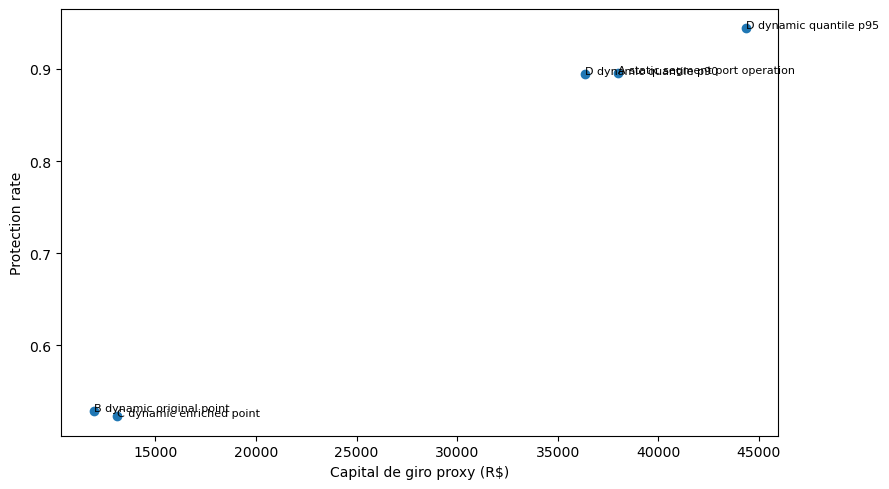

In [47]:
base_stock = safety_stock_simulation.query("scenario == 'base'").copy()
plt.figure(figsize=(9, 5))
plt.scatter(base_stock["proxy_working_capital_brl"], base_stock["protection_rate"])
for _, row in base_stock.iterrows():
    plt.annotate(row["policy"].replace("_", " "), (row["proxy_working_capital_brl"], row["protection_rate"]), fontsize=8)
plt.xlabel("Capital de giro proxy (R$)")
plt.ylabel("Protection rate")
plt.tight_layout()
plt.savefig(RUN_FIGURES / "safety_stock_tradeoff.png", dpi=160)
plt.show()

# 38. Síntese final do notebook

A síntese abaixo usa apenas variáveis calculadas durante a execução do notebook. Ela resume predição pontual, cauda, features históricas, quantis e simulação de estoque.

In [48]:
quantile_width_final = float(
    quantile_comparison.query("feature_config == 'ENRICHED_SAFE_HISTORY' and dataset == 'final_test'")["mean_width_p95_p50_h"].iloc[0]
)
synthesis = pd.DataFrame(
    [
        {"bloco": "predição pontual", "resultado": f"{winner['model']} + {winner['feature_config']} selecionado em validation; ganho final de MAE = {mae_gain_h:.3f} h ({mae_gain_pct:.2f}%)."},
        {"bloco": "cauda", "resultado": f"MAE Q95 enriched = {tail_comparison.loc[tail_comparison['feature_config']=='ENRICHED_SAFE_HISTORY', 'mae_q95'].iloc[0]:.3f} h; eventos extremos continuam difíceis."},
        {"bloco": "features históricas", "resultado": f"{len(enriched_features) - len(original_features)} colunas históricas adicionais reconstruídas com cutoff temporal seguro."},
        {"bloco": "regressão quantílica", "resultado": f"P95-P50 médio no final_test enriched = {quantile_width_final:.3f} h."},
        {"bloco": "estoque", "resultado": "A simulação evidencia trade-off entre proteção e capital de giro proxy, sem afirmar economia real observada."},
    ]
)
synthesis

,bloco,resultado
0,predição pontual,HistGradientBoosting + ENRICHED_SAFE_HISTORY s...
1,cauda,MAE Q95 enriched = 292.101 h; eventos extremos...
2,features históricas,74 colunas históricas adicionais reconstruídas...
3,regressão quantílica,P95-P50 médio no final_test enriched = 134.785 h.
4,estoque,A simulação evidencia trade-off entre proteção...


# 39. Verificação opcional contra resultados canônicos

Somente nesta seção os artefatos de `results/cap4_rebuild/` podem ser lidos. Eles servem apenas para comparar o resultado recém-calculado pelo notebook contra a execução canônica.

In [49]:
OFFICIAL_RESULTS = ROOT / "results" / "cap4_rebuild"
verification_rows = []
if (OFFICIAL_RESULTS / "point_model_comparison_final.csv").exists():
    official_final = pd.read_csv(OFFICIAL_RESULTS / "point_model_comparison_final.csv")
    for config in ["ORIGINAL", "ENRICHED_SAFE_HISTORY"]:
        notebook_mae = float(final_comparison.loc[final_comparison["feature_config"] == config, "mae"].iloc[0])
        official_mae = float(official_final.loc[official_final["feature_config"] == config, "mae"].iloc[0])
        verification_rows.append({"metric": f"final_mae_{config}", "notebook": notebook_mae, "official": official_mae, "delta": notebook_mae - official_mae})
if (OFFICIAL_RESULTS / "quantile_model_comparison.csv").exists():
    official_quantile = pd.read_csv(OFFICIAL_RESULTS / "quantile_model_comparison.csv")
    nb_q = quantile_comparison.query("model == 'hgb_quantile_log' and feature_config == 'ENRICHED_SAFE_HISTORY' and dataset == 'final_test'").iloc[0]
    off_q = official_quantile.query("model == 'hgb_quantile_log' and feature_config == 'ENRICHED_SAFE_HISTORY' and dataset == 'final_test'").iloc[0]
    for metric in ["pinball_p50", "pinball_p90", "pinball_p95", "mean_width_p95_p50_h"]:
        verification_rows.append({"metric": f"quantile_{metric}", "notebook": float(nb_q[metric]), "official": float(off_q[metric]), "delta": float(nb_q[metric] - off_q[metric])})
reproducibility_check = pd.DataFrame(verification_rows)
reproducibility_check.to_csv(RUN_RESULTS / "reproducibility_check.csv", index=False)
reproducibility_check

,metric,notebook,official,delta
0,final_mae_ORIGINAL,41.670,41.670,0.000
1,final_mae_ENRICHED_SAFE_HISTORY,38.351,38.351,0.000
2,quantile_pinball_p50,19.345,19.345,-0.000
3,quantile_pinball_p90,15.169,15.169,0.000
4,quantile_pinball_p95,10.702,10.702,0.000
5,quantile_mean_width_p95_p50_h,134.785,134.785,0.000
